# Post-Cavity Experiment â€” Context Mode

Comprehensive characterization using the **qubox_v2 v4** context-mode API
with explicit sample + cooldown scoping.

**Sections:**
1. Setup & Session Initialization
2. OPX/Octave Mixer Calibration
3. Readout Characterization
4. Qubit Characterization
5. Pulse Calibration
6. Readout Calibration
7. SPA Benchmarking
8. Storage Cavity
9. Quantum State Tomography
10. Session Verification & Summary
11. Context Mismatch Protection Demo
12. Utility: Continuous-Wave Output

All calibrations are automatically scoped to the active `sample_id + cooldown_id`.
Stale-calibration reuse across cooldowns is prevented by compatibility checks.

In [1]:
import sys
import numpy as np

# Ensure qubox_v2 is importable from the notebooks/ directory
sys.path.insert(0, r"E:\qubox")

from pathlib import Path
from qualang_tools.units import unit

from qubox_v2.experiments.session import SessionManager
from qubox_v2.experiments import (
    # Spectroscopy
    ResonatorSpectroscopy,
    ResonatorPowerSpectroscopy,
    ResonatorSpectroscopyX180,
    ReadoutTrace,
    QubitSpectroscopy,
    # Time domain
    PowerRabi,
    TemporalRabi,
    T1Relaxation,
    T2Ramsey,
    T2Echo,
    # Calibration
    IQBlob,
    ReadoutGEDiscrimination,
    ReadoutWeightsOptimization,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    AllXY,
    DRAGCalibration,
    RandomizedBenchmarking,
    PulseTrainCalibration,
    # Cavity / Fock
    StorageSpectroscopy,
    NumSplittingSpectroscopy,
    StorageChiRamsey,
    FockResolvedSpectroscopy,
    FockResolvedT1,
    FockResolvedRamsey,
    FockResolvedPowerRabi,
    # Tomography
    QubitStateTomography,
    StorageWignerTomography,
    SNAPOptimization,
    # SPA
    SPAFluxOptimization,
    SPAPumpFrequencyOptimization,
)
from qubox_v2.experiments.calibration import ReadoutConfig
from qubox_v2.calibration import CalibrationOrchestrator
from qubox_v2.devices import SampleRegistry, SampleInfo
from qubox_v2.core.session_state import SessionState
from qubox_v2.core.artifact_manager import ArtifactManager
from qubox_v2.core.preflight import preflight_check
from qubox_v2.core.artifacts import save_config_snapshot
from qubox_v2.core.schemas import validate_config_dir

u = unit()

2026-02-24 21:29:44,837 - qm - INFO     - Starting session: b47c7fbe-f317-49fe-89b8-f2bb586e49ea


## 1. Setup & Session Initialization

Idempotent setup: create or verify the sample and cooldown in the registry,
open a context-mode `SessionManager`, connect to QM hardware, and run
preflight checks.

**Directory layout:**
```
samples/<sample_id>/
  sample.json
  config/  (hardware.json, cqed_params.json, devices.json, pulse_specs.json)
  cooldowns/<cooldown_id>/
    config/  (calibration.json, pulses.json, measureConfig.json)
    data/
    artifacts/
```

In [2]:
# â”€â”€ Registry, Sample & Cooldown â”€â”€
REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"

registry = SampleRegistry(REGISTRY_BASE)

if not registry.sample_exists(SAMPLE_ID):
    registry.create_sample(
        SAMPLE_ID,
        description="Transmon qubit A â€” 3D cavity sample",
        config_source=Path(r"E:\qubox\seq_1_device\config"),
        metadata={"chip": "Q1-2025A", "fridge": "BlueFors-LD400"},
    )
    print(f"Created sample '{SAMPLE_ID}'")
else:
    print(f"Sample '{SAMPLE_ID}' exists")

if not registry.cooldown_exists(SAMPLE_ID, COOLDOWN_ID):
    registry.create_cooldown(
        SAMPLE_ID, COOLDOWN_ID,
        seed_from=Path(r"E:\qubox\seq_1_device\config"),
    )
    print(f"Created cooldown '{COOLDOWN_ID}'")
else:
    print(f"Cooldown '{COOLDOWN_ID}' exists")

info = registry.load_sample_info(SAMPLE_ID)
print(f"Sample: {info.sample_id} â€” {info.description}")
print(f"Cooldowns: {registry.list_cooldowns(SAMPLE_ID)}")

# â”€â”€ Session â”€â”€
session = SessionManager(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
    auto_save_calibration=True,
)
session.open()

ctx = session.context
attr = session.attributes
print(f"\nContext: sample={ctx.sample_id}  cooldown={ctx.cooldown_id}  wiring={ctx.wiring_rev}")
print(f"Config hash: {ctx.config_hash}  Schema: {ctx.schema_version}")
print(f"Experiment path: {session.experiment_path}")
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

cal_ctx = session.calibration.data.context
if cal_ctx:
    print(f"\nCalibration bound to sample={cal_ctx.sample_id} cooldown={cal_ctx.cooldown_id}")
else:
    print("\nNo context block in calibration (legacy v3 â€” will be stamped on first save)")

# Uncomment to run in simulation mode:
# session.hw.set_exec_mode("simulate")

Sample 'post_cavity_sample_A' exists
Cooldown 'cd_2025_02_22' exists
Sample: post_cavity_sample_A â€” Transmon qubit A — 3D cavity sample
Cooldowns: ['cd_2025_02_22']
[INFO] 2026-02-24 21:29:50,431 qubox.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=3f038c92
[INFO] 2026-02-24 21:29:50,431 qubox.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=3f038c92
[INFO] 2026-02-24 21:29:50,432 qubox.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
2026-02-24 21:29:54,101 - qm - INFO     - Performing health check
2026-02-24 21:29:54,106 - qm - INFO     - Health check passed
[INFO] 2026-02-24 21:29:54,130 qubox.calibration.store: Loading calibration from E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
[WARNING] 2026-02-24 21:29:54,132 qubox.calibration.store: Calibration file has no context block (le

Deprecated cqed_params keys loaded for backward compatibility: ['ro_therm_clks', 'qb_therm_clks', 'st_therm_clks', 'b_coherent_amp', 'b_coherent_len', 'b_alpha']


[INFO] 2026-02-24 21:29:56,794 qubox.experiments.session: SessionManager ready.
[INFO] 2026-02-24 21:29:58,164 qubox.experiments.session: Loaded measureMacro state from E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\measureConfig.json
[INFO] 2026-02-24 21:29:58,164 qubox.experiments.session: Synced measureMacro from CalibrationStore (element=resonator)
[INFO] 2026-02-24 21:29:58,165 qubox.experiments.session: Runtime element validation: available=['qubit', 'qubit2', 'resonator', 'resonator2', 'storage']

Context: sample=post_cavity_sample_A  cooldown=cd_2025_02_22  wiring=3f038c92
Config hash: 705865b204c1  Schema: 4.0.0
Experiment path: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
Resonator: 8.5962 GHz
Qubit:     6.1504 GHz
Storage:   5.2409 GHz

No context block in calibration (legacy v3 â€” will be stamped on first save)


### 1.1 Session Snapshot & Preflight Validation

Build an immutable `SessionState` snapshot (SHA-256 build hash), run preflight
validation, save a config snapshot artifact, and validate JSON schemas.

In [3]:
orch = CalibrationOrchestrator(session)

config_dir = Path(session.experiment_path) / "config"
sample_config_dir = getattr(session, "_sample_config_dir", None)
ss = SessionState.from_config_dir(
    config_dir,
    sample_config_dir=sample_config_dir,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    wiring_rev=ctx.wiring_rev,
)
am = ArtifactManager(session.experiment_path, ss.build_hash)
am.save_session_state(ss.to_dict())
print(ss.summary())
print(f"\nArtifacts root: {am.root}")

# Preflight validation
report = preflight_check(session)
if report["all_ok"]:
    print("All preflight checks PASSED.")
else:
    print("PREFLIGHT FAILURES:")
    for err in report["errors"]:
        print(f"  - {err}")

if report["warnings"]:
    print("Warnings:")
    for w in report["warnings"]:
        print(f"  - {w}")

snapshot_path = save_config_snapshot(session, tag="session_open")
print(f"\nConfig snapshot saved to: {snapshot_path}")

schema_results = validate_config_dir(config_dir)
print("\nSchema validation:")
for r in schema_results:
    status = "PASS" if r.valid else "FAIL"
    print(f"  {status} v={r.version}")
    for e in r.errors:
        print(f"    ERROR: {e}")
    for w in r.warnings:
        print(f"    WARN: {w}")

SessionState (build_hash=b41d0bb0329b)
  timestamp: 2026-02-24T21:29:58.221562
  git_commit: e1422f481787
  sample_id: post_cavity_sample_A
  cooldown_id: cd_2025_02_22
  wiring_rev: 3f038c92
  schemas:
    hardware: v1 (5074 bytes) — E:\qubox\samples\post_cavity_sample_A\config\hardware.json
    calibration: v4.0.0 (2075 bytes) — E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\calibration.json
    pulses: v2 (963267 bytes) — E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
  hardware elements: ['resonator', 'resonator2', 'qubit2', 'qubit', 'storage']
  calibration sections: ['discrimination', 'readout_quality', 'frequencies', 'coherence', 'pulse_calibrations']
  pulse specs: 1 definitions

Artifacts root: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\b41d0bb0329b
All preflight checks PASSED.

Config snapshot saved to: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\artifacts\config_snapshot_se

### 1.2 Readout Override

Configure which readout element, operation, demodulation method, and weights
are used by `measureMacro` for all subsequent experiments.

**Inputs:** element, operation, weights, demod method, threshold, weight length
**Outputs:** Updated `measureMacro` state, persisted `measureConfig.json`

In [ ]:
READOUT_OVERRIDE_ELEMENT = attr.ro_el
READOUT_OVERRIDE_OP = "readout"
READOUT_OVERRIDE_WEIGHTS = None
READOUT_OVERRIDE_DEMOD = "dual_demod.full"
READOUT_OVERRIDE_THRESHOLD = None
READOUT_OVERRIDE_WEIGHT_LEN = None

override_info = session.override_readout_operation(
    element=READOUT_OVERRIDE_ELEMENT,
    operation=READOUT_OVERRIDE_OP,
    weights=READOUT_OVERRIDE_WEIGHTS,
    demod=READOUT_OVERRIDE_DEMOD,
    threshold=READOUT_OVERRIDE_THRESHOLD,
    weight_len=READOUT_OVERRIDE_WEIGHT_LEN,
    apply_to_attributes=True,
    persist_measure_config=True,
    drive_frequency=attr.ro_fq,
)

print("Readout override applied:")
print(f"  element:    {override_info['element']}")
print(f"  operation:  {override_info['operation']}")
print(f"  pulse:      {override_info['pulse']}")
print(f"  ro_el:      {override_info['attributes_ro_el']}")
print(f"  QM mapping: {override_info['qm_config_entry']}")
print(f"  persisted:  {override_info['measure_config_path']}")

## 2. OPX/Octave Mixer Calibration

Calibrate IQ mixer offsets (DC offset, gain imbalance, phase imbalance) for
each element. Two paths are provided:

- **3.0 Auto Calibration** â€” QM/Octave built-in calibration (recommended first pass)
- **3.1 Manual Calibration** â€” SA124B-driven grid search or minimizer for fine-tuning

Run at least one path before any measurements to ensure clean signal generation.

### 2.0 Auto Calibration (Octave Built-in)

Uses QM's built-in Octave mixer calibration for all active elements.
Optionally validates results with a post-calibration SA measurement.

**NEEDS_RUN**: Requires QOP connection and Octave hardware.

In [4]:
hw = session.hw

elements = hw.get_active_mixer_elements()
if not elements:
    raise RuntimeError("No active mixer elements found in live QM config.")

el_los = hw.get_element_lo(elements)
el_ifs = hw.get_element_if(elements)

print("Mixer calibration targets (active elements):")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# --- Auto calibration (Octave built-in) ---
auto_results = hw.calibrate_element(
    el=None,
    method="auto",
    save_to_db=True,
    auto_sa_validate=True,
    auto_sa_device_name="sa124b",
)

print("\nAuto calibration complete.")
if hasattr(auto_results, "__iter__") and not isinstance(auto_results, (str, bytes, dict)):
    for r in auto_results:
        print(f"  {r}")
else:
    print(f"  {auto_results}")

Mixer calibration targets (active elements):
  qubit                 LO=6.2000 GHz  IF=-50.00 MHz
  storage               LO=5.4000 GHz  IF=-50.00 MHz
  resonator2            LO=3.5000 GHz  IF=-50.00 MHz
  qubit2                LO=7.0000 GHz  IF=-50.00 MHz
  resonator             LO=8.8000 GHz  IF=-50.00 MHz
2026-02-24 21:30:06,151 - qm - INFO     - Compiling program
2026-02-24 21:30:12,419 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:30:12,451 - qm - INFO     - Executing program
2026-02-24 21:30:16,898 - qm - INFO     - Compiling program
2026-02-24 21:30:23,012 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:30:23,084 - qm - INFO     - Executing program
2026-02-24 21:30:27,641 - qm - INFO     - Compiling program
2026-02-24 21:30:33,785 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:30:33,816 - qm - INFO     - Executing program
2026-02-24 21:30:38,480 - qm - INFO     - Compiling program


e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:225: RuntimeWarning: invalid value encountered in sqrt
  _n = np.sqrt(_I2c * _Q2c)
e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:225: RuntimeWarning: invalid value encountered in sqrt
  _n = np.sqrt(_I2c * _Q2c)
e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:130: RuntimeWarning: invalid value encountered in scalar divide
  x0_ = -p_[1] / (2 * p_[3])
e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:131: RuntimeWarning: invalid value encountered in scalar divide
  y0_ = -p_[2] / (2 * p_[5])
e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:130: RuntimeWarning: invalid value encountered in scalar divide
  x0_ = -p_[1] / (2 * p_[3])
e:\Program Files\Python311\Lib\site-packages\qm\octave\_calibration_analysis.py:131: RuntimeWarning: invalid value encountered in scalar divide
  y0_ = -p_

2026-02-24 21:30:43,339 - qm - WARNING  - At least one of the correction values are out of range. values should be between -2 and 2 - 2 ** (-16), got [nan, nan, nan, nan]. Not setting the correction matrix.
2026-02-24 21:30:44,649 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:30:44,681 - qm - INFO     - Executing program
2026-02-24 21:30:49,382 - qm - INFO     - Compiling program
2026-02-24 21:30:55,545 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:30:55,577 - qm - INFO     - Executing program

Auto mixer SA validation report (CW post-check):
Element               LO(dBc)   IRR(dBc)   Ptarget(dBm)
qubit                   56.04      34.60         -28.96
storage                 49.45      42.92         -26.50
resonator2              49.68      34.58         -30.95
qubit2                   0.08      -0.24         -87.75
resonator               44.49      44.72         -40.29

Auto calibration complete.
  None


### 2.1 Manual Calibration UX Controls

Configure logging, scan bounds/grid, spectrum analyser settings, and sideband
objective for the manual IQ calibration path. Skip to Section 4 if auto-cal
results are satisfactory.

**NEEDS_RUN**: Only needed when manual refinement is required.

In [5]:
# -------- Notebook-level UX toggles --------
QUIET_QM_LOGS = True
LIVE_PLOTS = True
LIVE_PLOT_EVERY = 1

# -------- Scan bounds / grid --------
DC_COARSE_RANGE = 0.10
DC_COARSE_N = 11
DC_FINE_RANGE = 0.02
DC_FINE_N = 11

IQ_GAIN_RANGE = 0.10
IQ_PHASE_RANGE = 0.20
IQ_COARSE_N = 11
IQ_FINE_GAIN_RANGE = 0.02
IQ_FINE_PHASE_RANGE = 0.04
IQ_FINE_N = 11

MIN_MAXITER = 60
MIN_XTOL = 1e-4

# -------- Spectrum analyzer settings --------
SA_SPAN_HZ = 2e6
SA_RBW = 10e3
SA_VBW = 10e3
SA_LEVEL_DBM = 0.0
SA_AVG = 1
SA_SETTLE_S = 0.0
SA_EXTRA_CONFIG = {}

# -------- Sideband targeting objective --------
SIDEBAND = "lsb"
OBJECTIVE_MODE = "weighted_sum"
W_CARRIER = 1.0
W_IMAGE = 1.0
W_TARGET = 1.0

print("Manual calibration controls set.")

Manual calibration controls set.


### 2.2 Manual IQ Calibration Run

Run the SA124B-driven manual mixer calibration for all active mixer elements.
Compares before/after LO leakage, image rejection, and target sideband power
for each element.

**NEEDS_RUN**: Requires SA124B spectrum analyser and QOP connection.

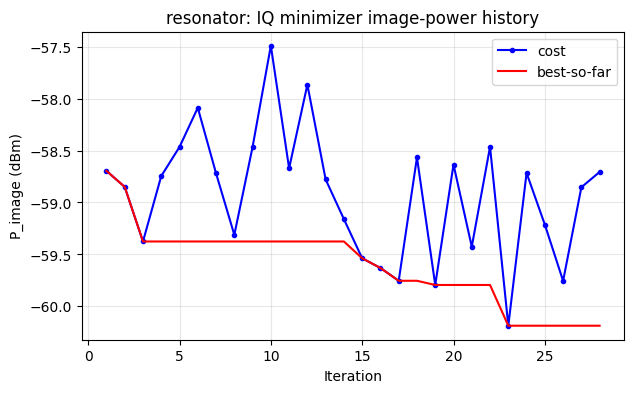

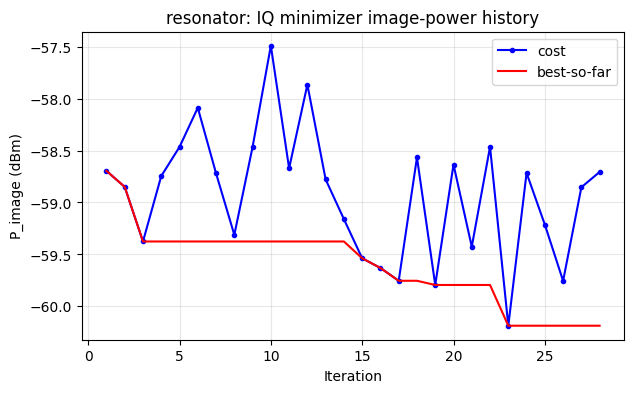

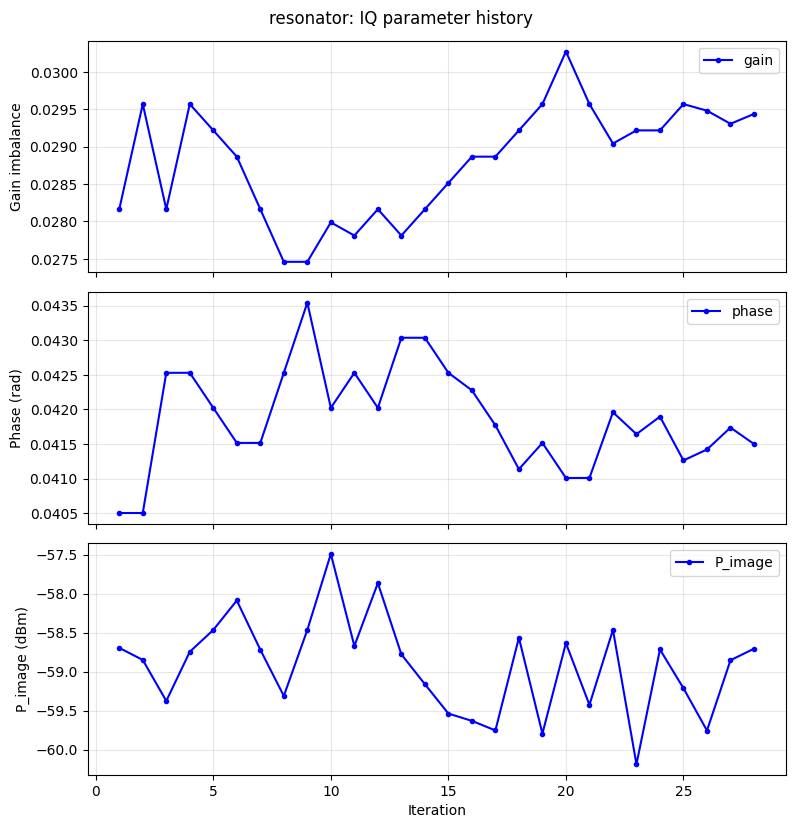

Manual minimizer result for 'resonator' is worse than baseline; reverting to baseline calibration.


2026-02-24 21:50:12,044 - qm - INFO     - Sending program to QOP for compilation
2026-02-24 21:50:12,074 - qm - INFO     - Executing program

  IQ Mixer Calibration — resonator
  LO:  8.800000 GHz
  IF:  -50.00 MHz
  Sideband target: LSB
------------------------------------------------------------
  P_target  @ 8.750000 GHz : -40.3 dBm
  P_LO   @ 8.800000 GHz : -61.3 dBm   (LO leak +21.1 dBc)
  P_image  @ 8.850000 GHz : -59.1 dBm   (IRR +18.8 dBc)
------------------------------------------------------------
  DC offsets:  I0 = -0.007226   Q0 = -0.012791
  IQ corr:     gain = +0.028164   phase = +0.040504 rad
------------------------------------------------------------
  Saved to calibration_db.json: NO


Manual calibration complete for all active elements.


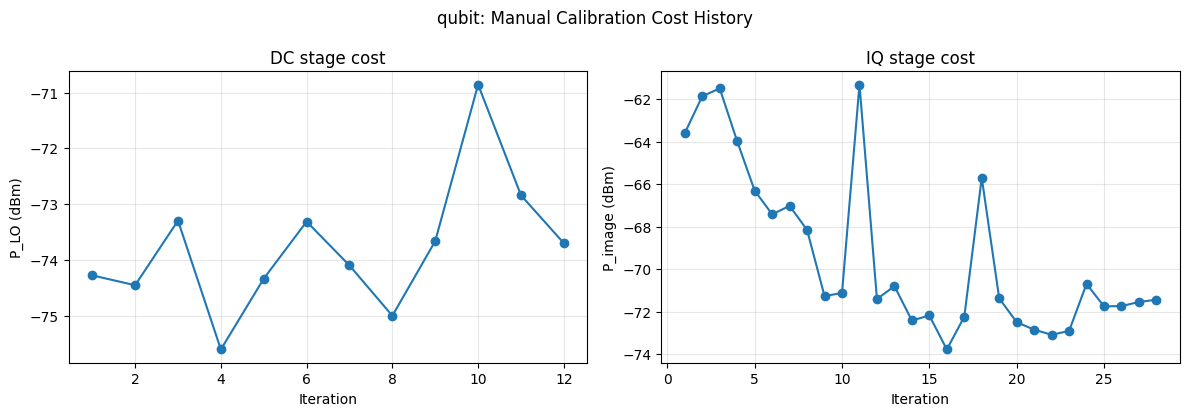

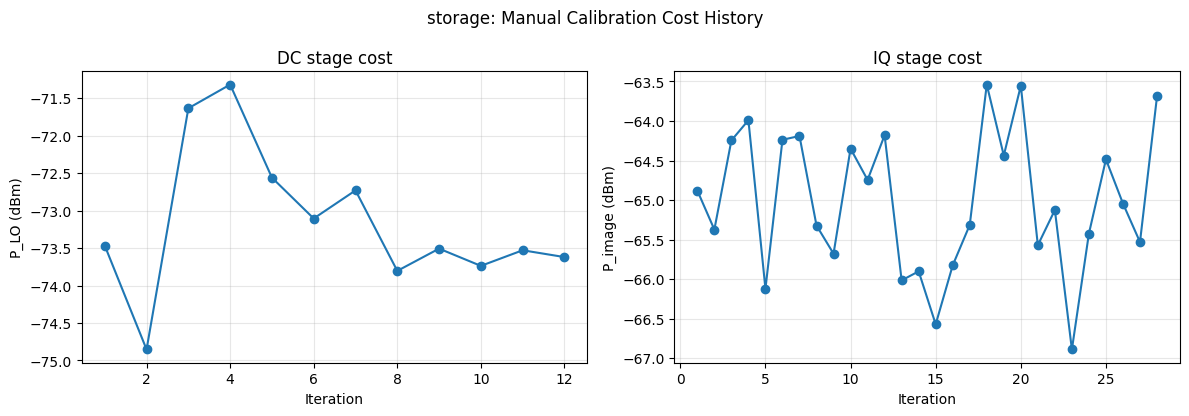

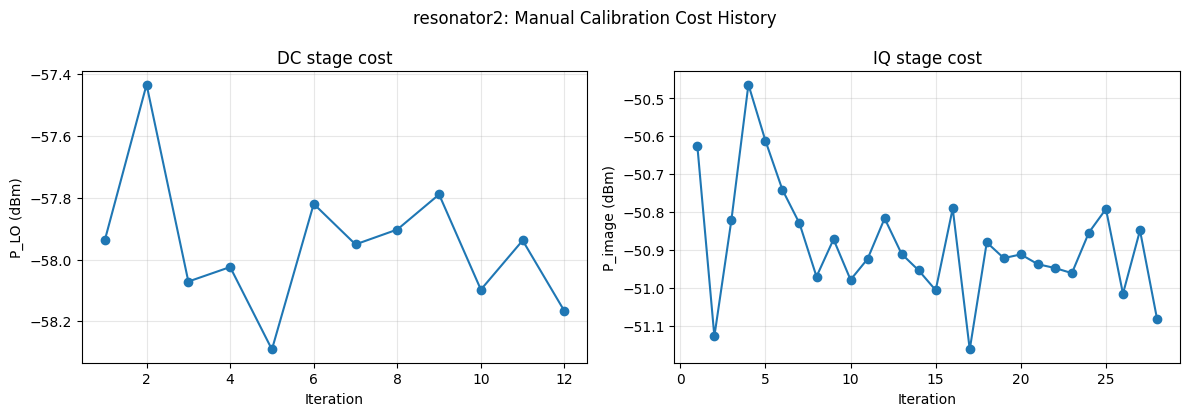

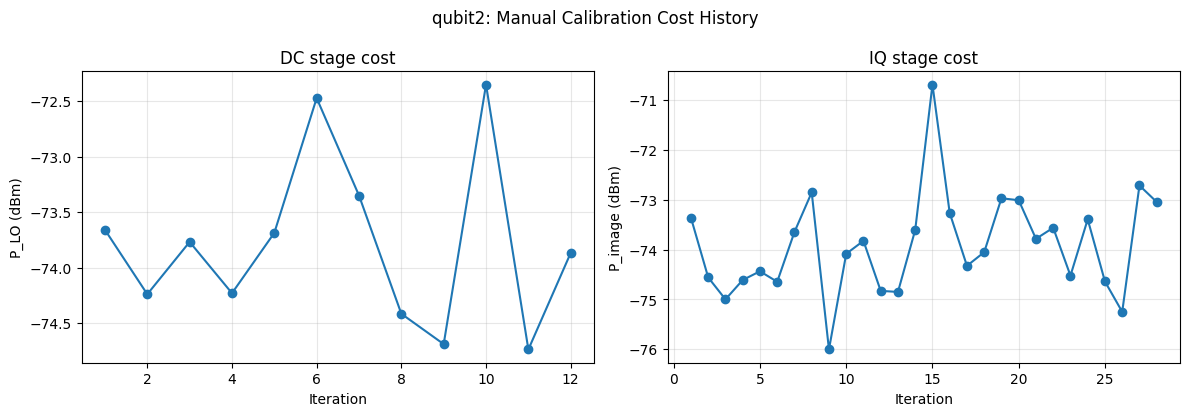

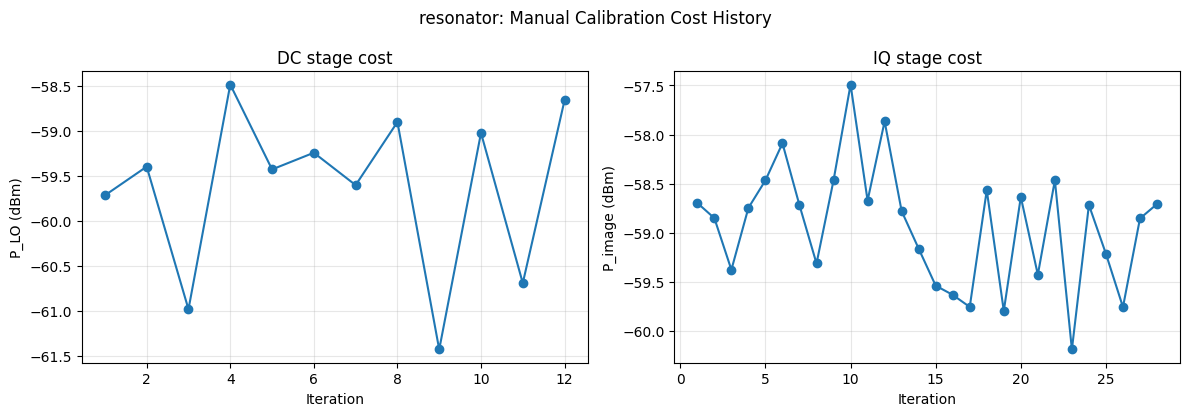


Suppression summary per element (powers in dBm, ratios in dBc):

--------------------------------------------------------------------------------------------------------------
Element: qubit
  Target sideband power (before/after):       -28.88 ->       -28.90
  LO power (before/after):                    -74.64 ->       -74.99
  Image sideband power (before/after):        -62.20 ->       -62.03
  Target/LO ratio dBc (before/after):          45.76 ->        46.09   (delta=    0.33)
  Target/Image ratio dBc (before/after):       33.32 ->        33.13   (delta=   -0.19)

--------------------------------------------------------------------------------------------------------------
Element: storage
  Target sideband power (before/after):       -26.42 ->       -26.41
  LO power (before/after):                    -72.74 ->       -72.20
  Image sideband power (before/after):        -64.18 ->       -64.07
  Target/LO ratio dBc (before/after):          46.32 ->        45.79   (delta=   -0.52)
 

In [ ]:
hw = session.hw

elements = hw.get_active_mixer_elements()
if not elements:
    raise RuntimeError("No active mixer elements found in live QM config.")

el_los = hw.get_element_lo(elements)
el_ifs = hw.get_element_if(elements)

print("Mixer calibration targets (active elements):")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# --- Manual IQ mixer calibration via SA124B ---
from qubox_v2.calibration import MixerCalibrationConfig
import matplotlib.pyplot as plt

cfg = MixerCalibrationConfig(
    sa_span_hz=SA_SPAN_HZ, sa_rbw=SA_RBW, sa_vbw=SA_VBW,
    sa_level=SA_LEVEL_DBM, sa_avg=SA_AVG, sa_settle=SA_SETTLE_S,
    sa_extra_config=SA_EXTRA_CONFIG,
    dc_coarse_range=DC_COARSE_RANGE, dc_coarse_n=DC_COARSE_N,
    dc_fine_range=DC_FINE_RANGE, dc_fine_n=DC_FINE_N,
    iq_gain_range=IQ_GAIN_RANGE, iq_phase_range=IQ_PHASE_RANGE,
    iq_coarse_n=IQ_COARSE_N,
    iq_fine_range_gain=IQ_FINE_GAIN_RANGE,
    iq_fine_range_phase=IQ_FINE_PHASE_RANGE,
    iq_fine_n=IQ_FINE_N,
    minimizer_maxiter=MIN_MAXITER, minimizer_xtol=MIN_XTOL,
    quiet_qm_logs=QUIET_QM_LOGS, live_plot=LIVE_PLOTS,
    live_plot_every=LIVE_PLOT_EVERY,
    sideband=SIDEBAND, objective_mode=OBJECTIVE_MODE,
    w_carrier=W_CARRIER, w_image=W_IMAGE, w_target=W_TARGET,
)

manual_results = []
for target_el, target_lo, target_if in zip(elements, el_los, el_ifs):
    target_lo = float(target_lo)
    target_if = float(target_if)

    print(f"\nCalibrating '{target_el}'...")
    result = hw.calibrate_element(
        el=target_el, method="manual_minimizer",
        mixer_cal_config=cfg, save_to_db=False,
    )
    manual_results.append(result)

print("\nManual calibration complete for all active elements.")

# --- Final plotting: combined history plots (per element) ---
for result in manual_results:
    el = result.get("element", "unknown")
    dc_hist = result.get("dc_history") or {}
    iq_hist = result.get("iq_history") or {}

    i0_hist = list(dc_hist.get("i0", []))
    q0_hist = list(dc_hist.get("q0", []))
    p_lo_hist = list(dc_hist.get("p_lo_dbm", []))

    gain_hist = list(iq_hist.get("gain", []))
    phase_hist = list(iq_hist.get("phase", []))
    p_img_hist = list(iq_hist.get("p_image_dbm", []))

    # DC history: I0, Q0 and P_LO on same plot (dual y-axis)
    fig, ax_left = plt.subplots(figsize=(11.5, 4.2))
    x_dc = range(1, max(len(i0_hist), len(q0_hist), len(p_lo_hist)) + 1)

    if i0_hist:
        ax_left.plot(range(1, len(i0_hist) + 1), i0_hist, "o-", lw=1.4, label="I0 offset")
    if q0_hist:
        ax_left.plot(range(1, len(q0_hist) + 1), q0_hist, "o-", lw=1.4, label="Q0 offset")
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("I/Q offsets")
    ax_left.grid(alpha=0.3)

    ax_right = ax_left.twinx()
    if p_lo_hist:
        ax_right.plot(range(1, len(p_lo_hist) + 1), p_lo_hist, "s--", lw=1.4, color="tab:red", label="P_LO (dBm)")
    ax_right.set_ylabel("P_LO (dBm)")

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")
    ax_left.set_title(f"{el}: DC Stage History (I0, Q0, P_LO)")
    plt.tight_layout()
    plt.show()

    # IQ history: gain, phase and P_image on same plot (dual y-axis)
    fig, ax_left = plt.subplots(figsize=(11.5, 4.2))
    x_iq = range(1, max(len(gain_hist), len(phase_hist), len(p_img_hist)) + 1)

    if gain_hist:
        ax_left.plot(range(1, len(gain_hist) + 1), gain_hist, "o-", lw=1.4, label="Gain imbalance")
    if phase_hist:
        ax_left.plot(range(1, len(phase_hist) + 1), phase_hist, "o-", lw=1.4, label="Phase (rad)")
    ax_left.set_xlabel("Iteration")
    ax_left.set_ylabel("Gain / Phase")
    ax_left.grid(alpha=0.3)

    ax_right = ax_left.twinx()
    if p_img_hist:
        ax_right.plot(range(1, len(p_img_hist) + 1), p_img_hist, "s--", lw=1.4, color="tab:red", label="P_image (dBm)")
    ax_right.set_ylabel("P_image (dBm)")

    lines_left, labels_left = ax_left.get_legend_handles_labels()
    lines_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc="best")
    ax_left.set_title(f"{el}: IQ Stage History (Gain, Phase, P_image)")
    plt.tight_layout()
    plt.show()

# --- Extensive suppression printout / table ---
def _safe_float(v):
    try:
        return float(v)
    except Exception:
        return float("nan")

def _ratio_factor(p_target_dbm, p_unwanted_dbm):
    if (p_target_dbm != p_target_dbm) or (p_unwanted_dbm != p_unwanted_dbm):
        return float("nan")
    return 10.0 ** ((p_target_dbm - p_unwanted_dbm) / 10.0)

def _fmt(v, width=12, prec=2):
    if v != v:
        return f"{'nan':>{width}s}"
    return f"{v:>{width}.{prec}f}"

def _fmt_ratio(v, width=14):
    if v != v:
        return f"{'nan':>{width}s}"
    return f"{v:>{width}.3e}"

table_rows = []
for result in manual_results:
    el = str(result.get("element", "unknown"))
    baseline = result.get("baseline_before_manual", {}) or {}

    p_t_before = _safe_float(baseline.get("P_des_dBm"))
    p_lo_before = _safe_float(baseline.get("P_LO_dBm"))
    p_img_before = _safe_float(baseline.get("P_img_dBm"))

    p_t_after = _safe_float(result.get("P_des_dBm"))
    p_lo_after = _safe_float(result.get("P_LO_dBm"))
    p_img_after = _safe_float(result.get("P_img_dBm"))

    ratio_t_lo_before = _ratio_factor(p_t_before, p_lo_before)
    ratio_t_img_before = _ratio_factor(p_t_before, p_img_before)
    ratio_t_lo_after = _ratio_factor(p_t_after, p_lo_after)
    ratio_t_img_after = _ratio_factor(p_t_after, p_img_after)

    table_rows.append({
        "element": el,
        "P_t_before": p_t_before,
        "P_lo_before": p_lo_before,
        "P_img_before": p_img_before,
        "R_t_lo_before": ratio_t_lo_before,
        "R_t_img_before": ratio_t_img_before,
        "P_t_after": p_t_after,
        "P_lo_after": p_lo_after,
        "P_img_after": p_img_after,
        "R_t_lo_after": ratio_t_lo_after,
        "R_t_img_after": ratio_t_img_after,
        "R_t_lo_improve": ratio_t_lo_after / ratio_t_lo_before if ratio_t_lo_before not in (0.0, float('nan')) else float('nan'),
        "R_t_img_improve": ratio_t_img_after / ratio_t_img_before if ratio_t_img_before not in (0.0, float('nan')) else float('nan'),
        "dBc_t_lo_after": _safe_float(result.get("LO_leak_dBc", p_t_after - p_lo_after)),
        "dBc_t_img_after": _safe_float(result.get("IRR_dBc", p_t_after - p_img_after)),
    })

print("\nSuppression summary per element (powers in dBm, ratios are linear factors):")
for row in table_rows:
    print("\n" + "-" * 130)
    print(f"Element: {row['element']}")
    print(f"  Target sideband power (before/after): {_fmt(row['P_t_before'])} -> {_fmt(row['P_t_after'])}")
    print(f"  LO power (before/after):              {_fmt(row['P_lo_before'])} -> {_fmt(row['P_lo_after'])}")
    print(f"  Image sideband power (before/after):  {_fmt(row['P_img_before'])} -> {_fmt(row['P_img_after'])}")
    print(f"  Target/LO ratio factor (before/after):   {_fmt_ratio(row['R_t_lo_before'])} -> {_fmt_ratio(row['R_t_lo_after'])}  (x{_fmt_ratio(row['R_t_lo_improve'], width=9).strip()})")
    print(f"  Target/Image ratio factor (before/after):{_fmt_ratio(row['R_t_img_before'])} -> {_fmt_ratio(row['R_t_img_after'])}  (x{_fmt_ratio(row['R_t_img_improve'], width=9).strip()})")
    print(f"  Final dBc (for reference): target/LO={_fmt(row['dBc_t_lo_after'], width=8)} dBc, target/image={_fmt(row['dBc_t_img_after'], width=8)} dBc")

print("\n" + "=" * 220)
header = (
    f"{'Element':18s}"
    f"{'P_t_b':>10s}{'P_LO_b':>10s}{'P_IMG_b':>10s}"
    f"{'R_t/LO_b':>14s}{'R_t/IMG_b':>14s}"
    f"{'P_t_a':>10s}{'P_LO_a':>10s}{'P_IMG_a':>10s}"
    f"{'R_t/LO_a':>14s}{'R_t/IMG_a':>14s}"
    f"{'xImp_LO':>12s}{'xImp_IMG':>12s}"
    f"{'dBc_t/LO':>10s}{'dBc_t/IMG':>11s}"
)
print(header)
print("-" * len(header))
for row in table_rows:
    line = (
        f"{row['element']:18s}"
        f"{_fmt(row['P_t_before'], 10)}{_fmt(row['P_lo_before'], 10)}{_fmt(row['P_img_before'], 10)}"
        f"{_fmt_ratio(row['R_t_lo_before'], 14)}{_fmt_ratio(row['R_t_img_before'], 14)}"
        f"{_fmt(row['P_t_after'], 10)}{_fmt(row['P_lo_after'], 10)}{_fmt(row['P_img_after'], 10)}"
        f"{_fmt_ratio(row['R_t_lo_after'], 14)}{_fmt_ratio(row['R_t_img_after'], 14)}"
        f"{_fmt_ratio(row['R_t_lo_improve'], 12)}{_fmt_ratio(row['R_t_img_improve'], 12)}"
        f"{_fmt(row['dBc_t_lo_after'], 10)}{_fmt(row['dBc_t_img_after'], 11)}"
    )
    print(line)
print("=" * 220)

## 3. Readout Characterization

### 3.1 Readout Trace

Acquire raw ADC traces to verify readout signal level and timing.

In [ ]:
trace = ReadoutTrace(session)
result = trace.run(attr.ro_fq, n_avg=10000)

analysis = trace.analyze(result)
trace.plot(analysis)
print(analysis.metrics)

### 3.2 Resonator Spectroscopy

Sweep readout frequency to locate resonator resonance.

In [ ]:
spec = ResonatorSpectroscopy(session)
res_cycle = orch.run_analysis_patch_cycle(
    spec,
    run_kwargs={
        "readout_op": "readout",
        "rf_begin": 8560 * u.MHz,
        "rf_end": 8640 * u.MHz,
        "df": 200 * u.kHz,
        "n_avg": 10000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

res_result = orch._run_result_from_artifact(res_cycle["artifact"])
res_analysis = spec.analyze(res_result, update_calibration=False)
spec.plot(res_analysis)
print(f"f0 = {res_cycle['calibration_result'].params.get('f0_MHz', float('nan')):.4f} MHz")
print(f"kappa = {res_cycle['calibration_result'].params.get('kappa', float('nan')) / 1e3:.1f} kHz")
print("Patch preview:")
for item in res_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(res_cycle["patch"], dry_run=False)

### 3.3 Resonator Power Spectroscopy

2D sweep of readout frequency vs gain to find optimal readout power.

In [ ]:
pspec = ResonatorPowerSpectroscopy(session)
result = pspec.run(
    "readout",
    rf_begin=8590 * u.MHz,
    rf_end=8600 * u.MHz,
    df=50 * u.kHz,
    g_min=0.01,
    g_max=1.9,
    N_a=20,
    n_avg=5000,
)

analysis = pspec.analyze(result)
pspec.plot(analysis)
print(f"Optimal gain: {analysis.metrics.get('optimal_gain', 'N/A')}")
print(f"Optimal freq: {analysis.metrics.get('optimal_freq', 'N/A')}")

### 3.4 Resonator Spectroscopy with X180

Measure resonator with ground and excited qubit states to extract dispersive shift chi.

In [ ]:
spec_x180 = ResonatorSpectroscopyX180(session)
result = spec_x180.run(
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec_x180.analyze(result, update_calibration=True)
spec_x180.plot(analysis)
print(f"f0_g = {analysis.metrics.get('f0_g', 0) / 1e6:.4f} MHz")
print(f"f0_e = {analysis.metrics.get('f0_e', 0) / 1e6:.4f} MHz")
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")

## 4. Qubit Characterization

### 4.1 Qubit Spectroscopy

Sweep qubit drive frequency to locate the qubit transition.
Updates qubit frequency in the cooldown-scoped calibration store.

In [ ]:
qb_spec = QubitSpectroscopy(session)
qb_cycle = orch.run_analysis_patch_cycle(
    qb_spec,
    run_kwargs={
        "pulse": "saturation",
        "rf_begin": 6130 * u.MHz,
        "rf_end": 6170 * u.MHz,
        "df": 500 * u.kHz,
        "qb_gain": 1.0,
        "qb_len": 1000,
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

qb_result = orch._run_result_from_artifact(qb_cycle["artifact"])
qb_analysis = qb_spec.analyze(qb_result, update_calibration=False)
qb_spec.plot(qb_analysis)
print(f"f0 = {qb_cycle['calibration_result'].params['f0_MHz']:.4f} MHz")
print("Patch preview:")
for item in qb_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(qb_cycle["patch"], dry_run=False)

### 4.2 Power Rabi

Sweep qubit drive amplitude to calibrate the pi pulse gain.
Updates `ref_r180` amplitude and derived primitives (cooldown-scoped).

In [ ]:
import importlib
import qubox_v2.calibration.orchestrator as orch_mod
importlib.reload(orch_mod)

orch = orch_mod.CalibrationOrchestrator(session)
rabi = PowerRabi(session)
rabi_cycle = orch.run_analysis_patch_cycle(
    rabi,
    run_kwargs={
        "max_gain": 1.2,
        "dg": 0.04,
        "op": "ref_r180",
        "n_avg": 5000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0.0001, 1, 0],
    },
    apply=False,
    persist_artifact=True,
)

rabi_result = orch._run_result_from_artifact(rabi_cycle["artifact"])
rabi_analysis = rabi.analyze(rabi_result, update_calibration=False, p0=[0.0001, 1, 0])
rabi.plot(rabi_analysis)
rabi_g_pi = float(rabi_cycle["calibration_result"].params.get("g_pi", 1.0))
print(f"g_pi (ref_r180) = {rabi_g_pi:.6f}")
print("Patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(rabi_cycle["patch"], dry_run=False)

### 4.3 Temporal Rabi

Sweep pulse duration at fixed amplitude to measure Rabi frequency.

In [ ]:
trabi = TemporalRabi(session)
result = trabi.run(
    pulse="const",
    pulse_len_begin=16,
    pulse_len_end=500,
    dt=4,
    n_avg=5000,
)

analysis = trabi.analyze(result)
trabi.plot(analysis)
print(f"f_Rabi = {analysis.metrics.get('f_Rabi', 'N/A')} Hz")
print(f"pi_length = {analysis.metrics.get('pi_length', 'N/A')} ns")

### 4.4 T1 Relaxation

Measure energy relaxation time after a pi pulse.
Stores T1 result in the cooldown-scoped calibration.

In [ ]:
t1 = T1Relaxation(session)
t1_cycle = orch.run_analysis_patch_cycle(
    t1,
    run_kwargs={
        "delay_end": 50 * u.us,
        "dt": 500,
        "n_avg": 2000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 10, 0],
        "p0_time_unit": "us",
        "derive_qb_therm_clks": True,
        "clock_period_ns": 4.0,
    },
    apply=False,
    persist_artifact=True,
)

t1_result = orch._run_result_from_artifact(t1_cycle["artifact"])
t1_analysis = t1.analyze(t1_result, update_calibration=False, p0=[0, 10, 0], p0_time_unit="us")
t1.plot(t1_analysis)
print(f"T1 = {t1_cycle['calibration_result'].params.get('T1_us', float('nan')):.2f} us")
print(f"qb_therm_clks (proposed) = {t1_cycle['calibration_result'].params.get('qb_therm_clks', 'N/A')}")
print("Patch preview:")
for item in t1_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t1_cycle["patch"], dry_run=False)

### 4.5 T2 Ramsey

Ramsey interferometry with intentional detuning to measure T2*.
Applies frequency correction if configured (cooldown-scoped).

In [ ]:
t2r = T2Ramsey(session)
qb_det_MHz = 0.2
t2r_cycle = orch.run_analysis_patch_cycle(
    t2r,
    run_kwargs={
        "qb_detune": int(qb_det_MHz * 1e6),
        "delay_end": 40 * u.us,
        "dt": 100,
        "n_avg": 4000,
        "qb_detune_MHz": qb_det_MHz,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [0, 20, 1.0, qb_det_MHz, 0.0, 0],
        "p0_time_unit": "us",
        "p0_freq_unit": "MHz",
        "apply_frequency_correction": True,
        "freq_correction_sign": -1.0,
    },
    apply=False,
    persist_artifact=True,
)

t2r_result = orch._run_result_from_artifact(t2r_cycle["artifact"])
t2r_analysis = t2r.analyze(
    t2r_result,
    update_calibration=False,
    p0=[0, 20, 1.0, qb_det_MHz, 0.0, 0],
    p0_time_unit="us",
    p0_freq_unit="MHz",
)
t2r.plot(t2r_analysis)
print(f"T2* = {t2r_cycle['calibration_result'].params.get('T2_star_us', float('nan')):.2f} us")
print(f"f_det = {t2r_cycle['calibration_result'].params.get('f_det_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in t2r_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2r_cycle["patch"], dry_run=False)

### 4.6 T2 Echo

Hahn echo measurement for T2_echo (removing low-frequency dephasing).

In [ ]:
t2e = T2Echo(session)
t2e_cycle = orch.run_analysis_patch_cycle(
    t2e,
    run_kwargs={
        "delay_end": 40 * u.us,
        "dt": 100,
        "n_avg": 4000,
    },
    analyze_kwargs={
        "update_calibration": True,
        "p0": [-1, 40, 1.0, 0],
        "p0_time_unit": "us",
    },
    apply=False,
    persist_artifact=True,
)

t2e_result = orch._run_result_from_artifact(t2e_cycle["artifact"])
t2e_analysis = t2e.analyze(t2e_result, update_calibration=False, p0=[-1, 40, 1.0, 0], p0_time_unit="us")
t2e.plot(t2e_analysis)
print(f"T2_echo = {t2e_cycle['calibration_result'].params.get('T2_echo_us', float('nan')):.2f} us")
print("Patch preview:")
for item in t2e_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(t2e_cycle["patch"], dry_run=False)

### 4.7 Primitive Pulse Waveform Update

Apply the Power Rabi calibration (`g_pi`) to the reference pulse and regenerate
all qubit rotation waveforms.

In [ ]:
# Commit PowerRabi patch after manual preview approval
print("PowerRabi patch preview:")
for item in rabi_cycle["dry_run"]["preview"]:
    print(" ", item)

# Uncomment to commit the previewed patch:
# rabi_apply = orch.apply_patch(rabi_cycle["patch"], dry_run=False)
# print(rabi_apply)

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
primitive_amps = {}
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    primitive_amps[op_name] = getattr(pcal, "amplitude", None)

print("Primitive amplitudes (current store):")
for op_name in primitive_ops:
    print(f"  {op_name:5s} -> {primitive_amps[op_name]}")

## 5. Pulse Calibration

### 5.1 DRAG Calibration

Sweep DRAG coefficient to minimize leakage to the second excited state.
Stores DRAG alpha in the cooldown-scoped calibration.

In [ ]:
drag = DRAGCalibration(session)
drag_cycle = orch.run_analysis_patch_cycle(
    drag,
    run_kwargs={
        "amps": np.linspace(-0.5, 0.5, 20),
        "n_avg": 5000,
        "base_alpha": 1.0,
    },
    analyze_kwargs={
        "update_calibration": True,
    },
    apply=False,
    persist_artifact=True,
)

drag_result = orch._run_result_from_artifact(drag_cycle["artifact"])
drag_analysis = drag.analyze(drag_result, update_calibration=False)
drag.plot(drag_analysis)
print(f"Optimal alpha = {drag_cycle['calibration_result'].params.get('optimal_alpha', 'N/A')}")
print("Patch preview:")
for item in drag_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after quality review:
# orch.apply_patch(drag_cycle["patch"], dry_run=False)

### 5.1b DRAG Calibration Commit

Wrap the DRAG calibration result in a `CalibrationStateMachine` lifecycle
and commit via `CalibrationPatch` if the fit quality passes validation.

In [ ]:
from qubox_v2.calibration.state_machine import (
    CalibrationStateMachine, CalibrationState,
    CalibrationPatch, PatchValidation,
)

sm_drag = CalibrationStateMachine(experiment="drag_calibration")
sm_drag.transition(CalibrationState.CONFIGURED)
sm_drag.transition(CalibrationState.ACQUIRING)
sm_drag.transition(CalibrationState.ACQUIRED)
sm_drag.transition(CalibrationState.ANALYZING)

optimal_alpha = drag_analysis.metrics.get("optimal_alpha", None)

drag_cal = session.calibration.get_pulse_calibration("ref_r180")
old_drag = drag_cal.drag_coeff if (drag_cal and drag_cal.drag_coeff is not None) else 0.0

drag_patch = CalibrationPatch(experiment="drag_calibration")
drag_patch.add_change(
    path="pulse_calibrations.ref_r180.drag_coeff",
    old_value=float(old_drag),
    new_value=float(optimal_alpha) if optimal_alpha is not None else None,
)

alpha_valid = optimal_alpha is not None and np.isfinite(optimal_alpha)
bounds_ok = alpha_valid and abs(optimal_alpha) < 5.0

drag_patch.validation = PatchValidation(
    passed=alpha_valid and bounds_ok,
    checks={"alpha_finite": alpha_valid, "alpha_bounds": bounds_ok},
    reasons=[] if (alpha_valid and bounds_ok) else
            [f"optimal_alpha={optimal_alpha} out of range or invalid"],
)
drag_patch.metadata = {"optimal_alpha": optimal_alpha}
sm_drag.patch = drag_patch

sm_drag.transition(CalibrationState.ANALYZED)
sm_drag.transition(CalibrationState.PENDING_APPROVAL)

print(drag_patch.summary())

if drag_patch.is_approved():
    sm_drag.transition(CalibrationState.COMMITTING)
    sm_drag.transition(CalibrationState.COMMITTED)
    print(f"\nDRAG commit recorded: alpha = {optimal_alpha:.4f}")
    am.save_artifact("drag_calibration_patch", drag_patch.to_dict())
else:
    am.save_artifact("drag_calibration_candidate", drag_patch.to_dict())
    print("\nDRAG calibration NOT committed. Candidate saved as artifact.")

### 5.1c Pulse-Train Rotation Calibration (Tomography)

Full 3-axis qubit state tomography at each N with multiple preps.
Fits Bloch-vector evolution via DE+LS global optimisation to extract
amplitude error, phase error, detuning, and zeta (per-step Z rotation).
Converts to QubitRotation knob corrections (d_lambda, d_alpha, d_omega).

Uses the unified `run() -> analyze() -> plot()` protocol via `PulseTrainCalibration(session)`.

In [ ]:
from qm.qua import play, align
from qubox_v2.experiments.gates_legacy import QubitRotation

pt = PulseTrainCalibration(session)

theta = np.pi
phi = 0.0
N_values = np.arange(0, 80, 8)
n_avg = 20000

# Prep using primitives (x90/y90/xn90/yn90/x180)
def prep_e():  play("x180", attr.qb_el)
def prep_px(): play("y90", attr.qb_el)
def prep_mx(): play("yn90", attr.qb_el)
def prep_py(): play("xn90", attr.qb_el)
def prep_my(): play("x90", attr.qb_el)

prep_defs = {
    "g": None, "e": prep_e,
    "+x": prep_px, "+y": prep_py, "-x": prep_mx, "-y": prep_my,
}

# Gate under test
arb_rot = QubitRotation(theta, phi, ref_r180_pulse="ref_r180_pulse", build=True)
session.burn_pulses()

# Run tomography sweep
result = pt.run(
    arb_rot=arb_rot, prep_defs=prep_defs, N_values=N_values,
    n_avg=n_avg, theta=theta, phi=phi, verbose=True, sanity_check=True,
)

# Analyse â€” knob conversion requires dt_s and n_samp
_Iw, _Qw, waveform_len, marker = arb_rot.waveforms()
dt_s = float(getattr(attr, "dt_s", 1e-9))
n_samp = int(waveform_len)

analysis = pt.analyze(
    result, fit_zeta=True, multi_seed=True, seeds=range(1, 2),
    seed_select="ls", verbose=True,
    dt_s=dt_s, n_samp=n_samp, d_omega_sign=1.0,
    bounds={"delta": (-0.001, 0.001), "amp_err": (-0.05, +0.05),
            "phase_err": (-0.2, +0.2), "zeta": (-0.1, 0.1)},
)

# Plot
pt.plot(analysis, residual_mode="both")

# Print fit results and knob corrections
print(f"amp_err    = {analysis.metrics['amp_err']:+.4%}")
print(f"phase_err  = {analysis.metrics['phase_err']:+.6f} rad")
print(f"delta      = {analysis.metrics['delta']:+.6f} rad/pulse")
print(f"zeta       = {analysis.metrics['zeta']:+.6f} rad/step")
if "d_lambda" in analysis.metrics:
    print(f"d_lambda   = {analysis.metrics['d_lambda']:+.6e}")
    print(f"d_alpha    = {analysis.metrics['d_alpha']:+.6f} rad")
    print(f"d_omega    = {analysis.metrics['d_omega']:+.6e} rad/s")

### 5.1d Verify Run (Apply Knob Corrections)

Re-run pulse-train tomography with the fitted knob corrections applied to
the `QubitRotation` gate. Uses a 3-prep subset (g, +x, +y) at half `n_avg`
for faster verification.

**NEEDS_RUN**: Requires QOP connection.

In [ ]:
# Apply knob corrections from the initial fit and re-run tomography
APPLY_KNOBS = True

theta_v = theta
phi_v = phi

kwargs_knobs = {}
if APPLY_KNOBS and "d_lambda" in analysis.metrics:
    kwargs_knobs = dict(
        d_lambda=analysis.metrics["d_lambda"],
        d_alpha=analysis.metrics["d_alpha"],
        d_omega=analysis.metrics["d_omega"],
    )
    print(f"Applying knobs: d_lambda={kwargs_knobs['d_lambda']:+.6e}, "
          f"d_alpha={kwargs_knobs['d_alpha']:+.6f}, "
          f"d_omega={kwargs_knobs['d_omega']:+.6e}")

arb_rot_corrected = QubitRotation(
    theta_v, phi_v,
    ref_r180_pulse="ref_r180_pulse",
    build=True,
    **kwargs_knobs,
)
session.burn_pulses()

# Subset preps for verification
prep_defs_verify = {
    "g": None,
    "+x": prep_px,
    "+y": prep_py,
}

N_values_v = N_values
n_avg_v = n_avg // 2

result_v = pt.run(
    arb_rot=arb_rot_corrected, prep_defs=prep_defs_verify,
    N_values=N_values_v, n_avg=n_avg_v,
    theta=theta_v, phi=phi_v, verbose=True, sanity_check=True,
)
print("Verify run complete.")

### 5.1e Verify Analysis (Before vs After)

Compare angular deviation from ideal Bloch trajectories before and after
correction. No fitting is performed on verify data â€” purely a comparison
against zero-error expectations.

In [ ]:
# Analyse the verify run â€” compare before and after angular errors
analysis_v = pt.analyze(
    result_v, fit_zeta=False, verbose=False,
    dt_s=dt_s, n_samp=n_samp,
)

pt.plot(analysis_v, residual_mode="both")

# Angular comparison (if available in metrics)
print("\nVerify run metrics:")
for k in ["amp_err", "phase_err", "delta", "zeta"]:
    before = analysis.metrics.get(k, float("nan"))
    after = analysis_v.metrics.get(k, float("nan"))
    print(f"  {k:12s}  before={before:+.6f}  after={after:+.6f}")

print("\nKnobs applied:", kwargs_knobs)

### 5.1f Apply Corrections to All Standard Rotations

Broadcast the calibrated knob corrections to all pi/2 and pi rotation gates
(x90, y90, xn90, yn90, x180, y180) by rebuilding from the DRAG Gaussian
reference pulse with per-gate knob maps.

**NEEDS_RUN**: Requires `register_rotations_from_ref_iq` and pulse persistence.

In [ ]:
from qubox_v2.tools.waveforms import drag_gaussian_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq

# Knob values from the fit (edit after calibration)
d_lambda_90  = analysis.metrics.get("d_lambda", 0.0)
d_alpha_90   = analysis.metrics.get("d_alpha", 0.0)
d_omega_90   = 0.0

d_lambda_180 = d_lambda_90  # scale if needed
d_alpha_180  = d_alpha_90
d_omega_180  = 0.0

PI2_ROTS = ["x90", "y90", "xn90", "yn90"]
PI_ROTS  = ["x180", "y180"]

d_lambda_map = {k: float(d_lambda_90) for k in PI2_ROTS}
d_alpha_map  = {k: float(d_alpha_90)  for k in PI2_ROTS}
d_omega_map  = {k: float(d_omega_90)  for k in PI2_ROTS}
d_lambda_map.update({k: float(d_lambda_180) for k in PI_ROTS})
d_alpha_map.update({k: float(d_alpha_180)  for k in PI_ROTS})
d_omega_map.update({k: float(d_omega_180)  for k in PI_ROTS})

# Rebuild reference DRAG Gaussian pulse
pcal_ref = session.calibration.get_pulse_calibration("ref_r180")
ref_amp = getattr(pcal_ref, "amplitude", rabi_g_pi)
ref_len = getattr(pcal_ref, "length", 40)
ref_drag = getattr(pcal_ref, "drag_coeff", 0.0)
anh = float(getattr(attr, "anharmonicity", 0) or -200e6)

gauss_r180, drag_r180 = drag_gaussian_pulse_waveforms(
    amplitude=ref_amp, length=ref_len,
    alpha=ref_drag, anharmonicity=anh, subtracted=True,
)

pm = session.pulse_mgr
res = register_rotations_from_ref_iq(
    pm,
    ref_I=gauss_r180,
    ref_Q=drag_r180,
    element=attr.qb_el,
    rotations="all",
    make_r0=True,
    override=True,
    persist=True,
    d_lambda_map=d_lambda_map,
    d_alpha_map=d_alpha_map,
    d_omega_map=d_omega_map,
)
session.burn_pulses()
session.save_pulses()

print("Broadcast rotation knobs to all standard gates:")
for gate_name, (I, Q) in res.items():
    print(f"  {gate_name:6s}: len={len(I)}, max_I={max(abs(I)):.6f}, "
          f"d_lambda={d_lambda_map.get(gate_name, 0):.1f}, "
          f"d_alpha={d_alpha_map.get(gate_name, 0):.6f}")
print("\nPulses saved to disk.")

### 5.2 AllXY

21-point gate error diagnostic. Ideal result is the stepped staircase pattern.

In [ ]:
from qubox_v2.programs.macros.measure import measureMacro

allxy = AllXY(session)
result = allxy.run(n_avg=5000)
analysis = allxy.analyze(result)
allxy.plot(analysis)

print(f"Gate error = {analysis.metrics.get('gate_error', float('nan')):.4f}")
print(f"Observable = {analysis.metrics.get('observable', 'unknown')}")
print(f"State map  = {analysis.metrics.get('state_mapping', {})}")
print(f"Confusion correction used = {analysis.metrics.get('used_confusion_correction', False)}")
print(f"Confusion matrix present  = {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

In [ ]:
from qubox_v2.programs.macros.measure import measureMacro
confusion = measureMacro._ro_quality_params.get("confusion_matrix", None)
confusion

### 5.3 Randomized Benchmarking

Single-qubit Clifford RB for average gate fidelity.

In [ ]:
rb = RandomizedBenchmarking(session)
result = rb.run(
    m_list=[1, 5, 10, 20, 50, 100, 200],
    num_sequence=20,
    n_avg=1000,
)

analysis = rb.analyze(result, p0=[0.99, 0.5, 0.5])
rb.plot(analysis)
print(f"p = {analysis.metrics.get('p', 'N/A')}")
print(f"Avg gate fidelity = {analysis.metrics.get('avg_gate_fidelity', 'N/A')}")
print(f"Error per gate = {analysis.metrics.get('error_per_gate', 'N/A')}")

## 6. Readout Calibration

### 6.1 IQ Blob

Acquire IQ blobs for ground and excited states.

In [ ]:
iq = IQBlob(session)
result = iq.run("x180", n_runs=5000)

analysis = iq.analyze(result)
iq.plot(analysis)
print(f"Readout fidelity = {analysis.metrics.get('fidelity', 0):.2%}")

### 6.2 Readout Weight Optimization

Optimize integration weights using time-sliced g/e readout traces.

In [ ]:
wopt = ReadoutWeightsOptimization(session)
result = wopt.run(
    ro_op="readout",
    drive_frequency=attr.ro_fq,
    cos_w_key="cos",
    sin_w_key="sin",
    m_sin_w_key="minus_sin",
    num_div=1,
    r180="x180",
    n_avg=200_000,
    persist=True,
    set_measure_macro=True,
)

analysis = wopt.analyze(result)
wopt.plot(analysis)

print(f"trace_length     = {analysis.metrics.get('trace_length', 'N/A')}")
print(f"ge_diff_norm_max = {analysis.metrics.get('ge_diff_norm_max', 'N/A'):.4f}")
print(f"opt_cos_key      = {analysis.metrics.get('opt_cos_key', 'N/A')}")
print(f"opt_sin_key      = {analysis.metrics.get('opt_sin_key', 'N/A')}")
print(f"opt_m_sin_key    = {analysis.metrics.get('opt_m_sin_key', 'N/A')}")

### 6.3 GE Discrimination

Full discrimination analysis â€” rotation angle, threshold, confusion matrix.
Stores weights/threshold/confusion in the cooldown-scoped calibration.

In [ ]:
from qubox_v2.experiments.calibration.readout import ReadoutGEDiscrimination

ge = ReadoutGEDiscrimination(session)
result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50000,
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
)

analysis = ge.analyze(result, update_calibration=True)
ge.plot(analysis, show_rotated=True, interactive=False)
print(f"Fidelity = {analysis.metrics.get('fidelity', 0):.2f}%")
print(f"Angle = {analysis.metrics.get('angle', 0):.3f} rad")
print(f"Threshold = {analysis.metrics.get('threshold', 0):.4f}")

rp = getattr(ge, "_run_params", {})
print("\nResolved readout_ge mapping:")
print(f"  element_readout: {attr.ro_el}")
print(f"  operation:       {rp.get('measure_op')}")
print(f"  pulse key:       {getattr(rp.get('pulse_info', None), 'pulse', None)}")
print(f"  base weights:    cos={rp.get('base_cos_name')}, sin={rp.get('base_sin_name')}, m_sin={rp.get('base_m_sin_name')}")

if "gaussianity_g" in analysis.metrics:
    print(f"Gaussianity (g) = {analysis.metrics['gaussianity_g']:.3f}")
    print(f"Gaussianity (e) = {analysis.metrics['gaussianity_e']:.3f}")
if "cv_fidelity" in analysis.metrics:
    print(f"Cross-validated fidelity = {analysis.metrics['cv_fidelity']:.2%}")

### 6.4 Butterfly Measurement

Two successive measurements to quantify QND fidelity, F, Q, and V.

In [ ]:
from qubox_v2.experiments.calibration.readout import ReadoutButterflyMeasurement

bfly = ReadoutButterflyMeasurement(session)
result = bfly.run(r180="x180", update_measure_macro=True, n_samples=50000)

analysis = bfly.analyze(result, update_calibration=True)
bfly.plot(analysis, show_histogram=True, show_discriminator=True)
print(f"F = {analysis.metrics.get('F', 0):.2%}")
print(f"Q = {analysis.metrics.get('Q', 0):.2%}")
print(f"V = {analysis.metrics.get('V', 0):.4f}")

if "t01" in analysis.metrics:
    print(f"t01 = {analysis.metrics['t01']:.4f}")
    print(f"t10 = {analysis.metrics['t10']:.4f}")
if "Lambda_M_valid" in analysis.metrics:
    print(f"Lambda_M_valid = {analysis.metrics['Lambda_M_valid']}")

### 6.5 Full Readout Calibration Pipeline

Run the full state machine pipeline with explicit staged patch review and commit.
Stores all readout quality params in the cooldown-scoped calibration.

In [ ]:
import importlib
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import (
    CalibrationReadoutFull,
    ReadoutConfig,
    ReadoutGEDiscrimination,
    ReadoutButterflyMeasurement,
    ReadoutWeightsOptimization,
    CalibrateReadoutFull,
)
from qubox_v2.programs.macros.measure import measureMacro

LEGACY_BLOB_K = 3.0
LEGACY_M0_MAX_TRIALS = 1000

readoutConfig = ReadoutConfig(
    measure_op="readout",
    drive_frequency=attr.ro_fq,
    ro_el=attr.ro_el,
    r180="x180",
    n_avg_weights=200_000,
    n_samples=50_000,
    n_shots_butterfly=50_000,
    skip_weights_optimization=False,
    persist_weights=True,
    update_weights=True,
    update_threshold=True,
    rotation_method="optimal",
    weight_extraction_method="legacy_ge_diff_norm",
    histogram_fitting="two_state_discriminator",
    threshold_extraction="legacy_discriminator",
    overwrite_policy="override",
    blob_k_g=LEGACY_BLOB_K,
    blob_k_e=LEGACY_BLOB_K,
    M0_MAX_TRIALS=LEGACY_M0_MAX_TRIALS,
    save_to_config=True,
    save_calibration_json=True,
    save_calibration_db=False,
    save_measure_config=True,
    save_session_state=False,
    display_analysis=False,
    ge_kwargs={
        "auto_update_postsel": True,
        "apply_rotated_weights": True,
        "persist": True,
    },
    bfly_kwargs={
        "update_measure_macro": True,
        "show_analysis": False,
    },
)

cal = CalibrationReadoutFull(session)
ro_pipeline_result = cal.run(readoutConfig=readoutConfig)
ro_pipeline_analysis = cal.analyze(ro_pipeline_result, update_calibration=True)

ge_stage = ro_pipeline_analysis.metadata.get("ge_analysis")
bfly_stage = ro_pipeline_analysis.metadata.get("bfly_analysis")

ge_fid_frac = float(ro_pipeline_analysis.metrics.get("ge_fidelity", float("nan")))
if ge_fid_frac > 1.0 and np.isfinite(ge_fid_frac):
    ge_fid_frac = ge_fid_frac / 100.0
ge_fid_pct = ge_fid_frac * 100.0 if np.isfinite(ge_fid_frac) else float("nan")

bfly_F = float(ro_pipeline_analysis.metrics.get("bfly_F", float("nan")))
ge_minus_F = ge_fid_frac - bfly_F if (np.isfinite(ge_fid_frac) and np.isfinite(bfly_F)) else float("nan")

weights_mode = "optimized" if not readoutConfig.skip_weights_optimization else "base"
print("Readout calibration pipeline complete.")
print(f"Weight mode = {weights_mode}")
print(f"GE fidelity = {ge_fid_pct:.2f}%  ({ge_fid_frac:.4f} frac)")
print(f"GE angle    = {ro_pipeline_analysis.metrics.get('ge_angle', 0):.6f} rad")
print(f"GE thr      = {ro_pipeline_analysis.metrics.get('ge_threshold', 0):.6g}")
print(f"F = {ro_pipeline_analysis.metrics.get('bfly_F', 0):.4f}, Q = {ro_pipeline_analysis.metrics.get('bfly_Q', 0):.4f}, V = {ro_pipeline_analysis.metrics.get('bfly_V', 0):.4f}")
print(f"GE/100 - F  = {ge_minus_F:.4f}")
print(f"Lambda_M_valid = {ro_pipeline_analysis.metrics.get('bfly_Lambda_M_valid', None)}")
print(f"acceptance_rate = {ro_pipeline_analysis.metrics.get('bfly_acceptance_rate', float('nan'))}")
print(f"average_tries   = {ro_pipeline_analysis.metrics.get('bfly_average_tries', float('nan'))}")
print(f"readout_duration_ns   = {ro_pipeline_analysis.metrics.get('bfly_readout_duration_ns', float('nan'))}")
print(f"readout_duration_clks = {ro_pipeline_analysis.metrics.get('bfly_readout_duration_clks', float('nan'))}")
print(f"T1_decay_factor       = {ro_pipeline_analysis.metrics.get('bfly_T1_decay_factor', float('nan'))}")
print(f"measureMacro confusion loaded: {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

fq_entry = session.calibration.get_frequencies(attr.qb_el)
cal_qb_fq = None if fq_entry is None else getattr(fq_entry, "qubit_freq", None)
attr_qb_fq = getattr(attr, "qb_fq", None)
print("
Qubit frequency binding check:")
print(f"  calibration frequencies.{attr.qb_el}.qubit_freq = {cal_qb_fq}")
print(f"  runtime attr.qb_fq                               = {attr_qb_fq}")
if cal_qb_fq is not None and attr_qb_fq is not None:
    print(f"  delta (attr - calibrated)                        = {float(attr_qb_fq) - float(cal_qb_fq)} Hz")

if bfly_stage is not None:
    cm = bfly_stage.metrics.get("confusion_matrix", None)
    tm = bfly_stage.metrics.get("transition_matrix", None)
else:
    cm = None
    tm = None

if cm is not None:
    print("\nButterfly confusion matrix Lambda_M:")
    try:
        print(cm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(cm)
if tm is not None:
    print("\nButterfly transition matrix T:")
    try:
        print(tm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(tm)

ro_pipeline_summary = {
    "readoutConfig": readoutConfig,
    "result": ro_pipeline_result,
    "analysis": ro_pipeline_analysis,
    "parity": {
        "ge_fidelity_frac": ge_fid_frac,
        "F": bfly_F,
        "ge_minus_F": ge_minus_F,
    },
}

### 6.6 Readout Calibration Artifacts

Save all readout calibration metrics and state machine histories as
session artifacts. Validates persistence to cooldown-scoped paths.

In [ ]:
import importlib
from pathlib import Path
import qubox_v2.experiments.calibration.gates as gates_mod
importlib.reload(gates_mod)
from qubox_v2.experiments.calibration.gates import AllXY
from qubox_v2.programs.macros.measure import measureMacro

# Persist readout + pulse calibration artifacts (cooldown-scoped)
session.calibration.save()
session.save_pulses()
measure_cfg_path = Path(session.experiment_path) / "config" / "measureConfig.json"
measure_cfg_path.parent.mkdir(parents=True, exist_ok=True)
measureMacro.save_json(str(measure_cfg_path))

# Reload measureMacro from disk to validate persistence path
measureMacro.load_json(str(measure_cfg_path))

# Run ALLXY as post-readout sanity check
allxy = AllXY(session)
allxy_result = allxy.run(n_avg=5000)
allxy_analysis = allxy.analyze(allxy_result)
allxy.plot(allxy_analysis)

cm = measureMacro._ro_quality_params.get("confusion_matrix", None)
tm = measureMacro._ro_quality_params.get("transition_matrix", None)

print("=== Calibration Summary ===")
print(f"g_pi (ref_r180): {float(globals().get('rabi_g_pi', float('nan'))):.6f}")

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
print("Primitive pulse amplitudes:")
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    print(f"  {op_name:5s}: {getattr(pcal, 'amplitude', None)}")

if "ro_pipeline_analysis" in globals():
    _m = ro_pipeline_analysis.metrics
    print(f"GE fidelity: {_m.get('ge_fidelity')}")
    print(f"Rotation angle: {_m.get('ge_angle')}")
    print(f"F={_m.get('bfly_F')}, Q={_m.get('bfly_Q')}, V={_m.get('bfly_V')}")

print("Confusion matrix:")
print(cm)
print("Transition matrix:")
print(tm)
print(f"ALLXY observable: {allxy_analysis.metrics.get('observable')}")
print(f"ALLXY correction applied: {allxy_analysis.metrics.get('used_confusion_correction')}")
print(f"ALLXY state mapping: {allxy_analysis.metrics.get('state_mapping')}")
print("Final mapping: +1 -> |g>, -1 -> |e>")
print(f"measureConfig persisted to: {measure_cfg_path}")

## 7. SPA Benchmarking

### 7.1 SPA Flux Optimization

Sweep DC flux bias with SPA-enhanced readout to find optimal flux point.

In [ ]:
spa_flux = SPAFluxOptimization(session)
result = spa_flux.run(
    dc_list=np.linspace(-0.5, 0.5, 51),
    sample_fqs=np.linspace(8.5e9, 8.7e9, 21),
    n_avg=1000,
)

analysis = spa_flux.analyze(result)
spa_flux.plot(analysis)
print(f"Best DC = {analysis.metrics.get('best_dc', 'N/A'):.4f} V")
print(f"Best freq = {analysis.metrics.get('best_freq', 0) / 1e6:.2f} MHz")

### 7.2 SPA Pump Frequency Optimization

2D sweep of pump power and detuning to optimize SPA readout fidelity.

In [ ]:
spa_pump = SPAPumpFrequencyOptimization(session)
# result = spa_pump.run(
#     readout_op="readout",
#     drive_frequency=attr.qb_fq,
#     pump_powers=np.linspace(0.1, 1.0, 10),
#     pump_detunings=np.linspace(-5e6, 5e6, 21),
#     r180="x180",
#     samples_per_run=25000,
# )
# analysis = spa_pump.analyze(result)
# spa_pump.plot(analysis)
# print(f"Best pump power = {analysis.metrics.get('best_pump_power', 'N/A')}")
# print(f"Best pump detuning = {analysis.metrics.get('best_pump_detuning', 'N/A')}")

### 7.3 Register Storage Cavity Pulse Definitions

**Required** before running any storage cavity experiments.

Registers:
- `const_alpha` â€” constant displacement pulse on the storage element
- `sel_x180` and derived selective rotations (`sel_y180`, `sel_x90`, etc.) â€”
  Kaiser-windowed selective pi pulse for Fock-number-resolved qubit control

In [ ]:
from qubox_v2.tools.waveforms import kaiser_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq

pm = session.pulse_mgr

# ---- const_alpha: constant displacement pulse on storage ----
alpha_len = 48   # ns (must be >= 16, divisible by 4)
alpha_amp = 0.019580
b_alpha = 1.0

pm.create_control_pulse(
    element=attr.st_el,
    op="const_alpha",
    length=alpha_len,
    I_samples=[alpha_amp] * alpha_len,
    Q_samples=[0.0] * alpha_len,
    override=True,
    persist=False,
)

# Store displacement reference for ensure_displacement_ops
session._displacement_ref = {
    "coherent_amp": alpha_amp,
    "coherent_len": alpha_len,
    "b_alpha": b_alpha,
}

print(f"const_alpha registered: len={alpha_len}, amp={alpha_amp}, b_alpha={b_alpha}")

# ---- sel_x180: Kaiser-windowed selective pi pulse ----
sel_rlen = 1000   # ns
sel_kaiser_amp = 0.0013420737712946228
sel_beta = 7.967
anh = float(getattr(attr, "anharmonicity", 0) or -200e6)

sel_I, sel_Q = kaiser_pulse_waveforms(
    amplitude=sel_kaiser_amp,
    length=sel_rlen,
    beta=sel_beta,
    detuning=0.0,
    subtracted=True,
    alpha=0.0,
    anharmonicity=anh,
)

# Register ref + all derived rotations (sel_x180, sel_y180, sel_x90, etc.)
sel_ops = register_rotations_from_ref_iq(
    pm,
    ref_I=sel_I,
    ref_Q=sel_Q,
    element=attr.qb_el,
    prefix="sel_",
    rotations="all",
    make_r0=False,
    override=True,
    persist=False,
)

session.burn_pulses()

print(f"sel_x180 registered: len={sel_rlen}, amp={sel_kaiser_amp}, beta={sel_beta}")
print(f"Selective rotation ops: {list(sel_ops.keys())}")

## 8. Storage Cavity

### 8.1 Storage Spectroscopy

Sweep storage cavity frequency to locate resonance.

In [ ]:
st_spec = StorageSpectroscopy(session)
result = st_spec.run(
    disp="const_alpha",
    rf_begin=5200 * u.MHz,
    rf_end=5280 * u.MHz,
    df=200 * u.kHz,
    storage_therm_time=500,
    n_avg=50,
)

analysis = st_spec.analyze(result, update_calibration=True)
st_spec.plot(analysis)
print(f"f_storage = {analysis.metrics['f_storage'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 8.1b Storage Spectroscopy (Orchestrator Pipeline)

Run via the Artifact -> CalibrationResult -> Patch -> Orchestrator flow.

In [ ]:
st_spec = StorageSpectroscopy(session)
st_center = float(getattr(attr, "st_fq", attr.qb_fq))
st_cycle = orch.run_analysis_patch_cycle(
    st_spec,
    run_kwargs={
        "disp": "const_alpha",
        "rf_begin": (st_center - 5 * u.MHz),
        "rf_end": (st_center + 5 * u.MHz),
        "df": 200 * u.kHz,
        "storage_therm_time": int(getattr(attr, "qb_therm_clks", 0)),
        "sel_r180": "sel_x180",
        "n_avg": 1000,
    },
    analyze_kwargs={"update_calibration": True},
    apply=False,
    persist_artifact=True,
)

st_result = orch._run_result_from_artifact(st_cycle["artifact"])
st_analysis = st_spec.analyze(st_result, update_calibration=False)
st_spec.plot(st_analysis)
print(f"storage f0 = {st_cycle['calibration_result'].params.get('f_storage_MHz', float('nan')):.4f} MHz")
print("Patch preview:")
for item in st_cycle["dry_run"]["preview"]:
    print(" ", item)

# Commit only after review:
# orch.apply_patch(st_cycle["patch"], dry_run=False)

### 8.2 Number Splitting Spectroscopy

Resolve photon-number-dependent qubit frequency shifts.

In [ ]:
from qm.qua import wait

def prep_vacuum():
    """Explicit no-op preparation for notebook-driven workflows."""
    wait(1)

nsplit = NumSplittingSpectroscopy(session)
result = nsplit.run(
    rf_centers=[attr.qb_fq],
    rf_spans=[10 * u.MHz],
    df=100 * u.kHz,
    state_prep=prep_vacuum,
    n_avg=500,
)

analysis = nsplit.analyze(result)
nsplit.plot(analysis)
print(analysis.metrics)

### 8.3 Storage Chi Ramsey

Measure dispersive coupling chi via Ramsey interferometry.

In [ ]:
chi_ramsey = StorageChiRamsey(session)
result = chi_ramsey.run(
    fock_fq=attr.qb_fq,
    delay_ticks=np.arange(4, 2000, 10),
    disp_pulse="const_alpha",
    x90_pulse="x90",
    n_avg=20,
)

analysis = chi_ramsey.analyze(result, update_calibration=True,
                              p0=[0.5, 0.5, 35000, 0.1, 0.0028, 400])
chi_ramsey.plot(analysis)
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")
print(f"nbar = {analysis.metrics.get('nbar', 0):.2f}")

### 8.4 Fock-Resolved Spectroscopy

Probe qubit spectroscopy conditioned on Fock number.

In [ ]:
fock_spec = FockResolvedSpectroscopy(session)
result = fock_spec.run(
    probe_fqs=np.linspace(attr.qb_fq - 5e6, attr.qb_fq + 5e6, 101),
    state_prep=prep_vacuum,
    n_avg=20,
)

analysis = fock_spec.analyze(result)
fock_spec.plot(analysis)
print(analysis.metrics)

### 8.4b Register Displacement Pulses for Fock-Resolved Experiments

**REQUIRED** before running Fock-resolved T1, Ramsey, or Power Rabi.

In [ ]:
from qubox_v2.tools.generators import ensure_displacement_ops

n_fock = 3

disp_ref = getattr(session, '_displacement_ref', None) or session.get_displacement_reference()
coherent_amp = disp_ref.get("coherent_amp", None)
coherent_len = disp_ref.get("coherent_len", None)
b_alpha = disp_ref.get("b_alpha", None)

created = ensure_displacement_ops(
    session.pulse_mgr,
    element=attr.st_el,
    n_max=n_fock,
    coherent_amp=coherent_amp,
    coherent_len=coherent_len,
    b_alpha=b_alpha,
)

session.burn_pulses()

print(f"Displacement refs: amp={coherent_amp}, len={coherent_len}, alpha={b_alpha}")
print(f"Registered {len(created)} displacement ops on '{attr.st_el}':")
for name, (I, Q) in created.items():
    print(f"  {name}: len={len(I)}, max_I={I.max():.4f}, max_Q={Q.max():.4f}")

### 8.5 Fock-Resolved T1

Measure T1 in individual Fock manifolds.

In [ ]:
fock_t1 = FockResolvedT1(session)

n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_t1.run(
     fock_fqs=fock_fqs,
     fock_disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=200,
     n_avg=20,
)
analysis = fock_t1.analyze(result)
fock_t1.plot(analysis)
for key, val in analysis.metrics.items():
     if key.startswith("T1_fock_"):
         print(f"{key} = {val / 1e3:.2f} us")

### 8.6 Fock-Resolved Ramsey

Measure T2 in individual Fock manifolds.

In [ ]:
fock_ramsey = FockResolvedRamsey(session)

n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_ramsey.run(
     fock_fqs=fock_fqs,
     detunings=[0.2e6],
     disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=100,
     n_avg=20,
)
analysis = fock_ramsey.analyze(result)
fock_ramsey.plot(analysis)
print(analysis.metrics)

### 8.7 Fock-Resolved Power Rabi

Calibrate selective pi pulses per Fock manifold.

In [ ]:
fock_rabi = FockResolvedPowerRabi(session)
# fock_fqs = [...]  # From NumSplittingSpectroscopy results
# result = fock_rabi.run(
#     fock_fqs=fock_fqs,
#     gains=np.linspace(0, 1.5, 50),
#     sel_qb_pulse="sel_x180",
#     disp_n_list=["disp_n0", "disp_n1", "disp_n2"],
#     n_avg=2000,
# )
# analysis = fock_rabi.analyze(result)
# fock_rabi.plot(analysis)
# for key, val in analysis.metrics.items():
#     if key.startswith("g_pi_fock_"):
#         print(f"{key} = {val:.4f}")

## 9. Quantum State Tomography

### 9.1 Qubit State Tomography

Three-axis measurement to reconstruct the qubit Bloch vector.

In [ ]:
from qm.qua import *

def prep_x_plus():
    """Prepare |+x> state."""
    play("x90", attr.qb_el)

tomo = QubitStateTomography(session)
result = tomo.run(
    state_prep=prep_x_plus,
    n_avg=10000,
)

analysis = tomo.analyze(result)
tomo.plot(analysis)
print(f"sx = {analysis.metrics.get('sx', 0):.3f}")
print(f"sy = {analysis.metrics.get('sy', 0):.3f}")
print(f"sz = {analysis.metrics.get('sz', 0):.3f}")
print(f"Purity = {analysis.metrics.get('purity', 0):.3f}")

### 9.2 Wigner Tomography

Reconstruct the Wigner function of the storage cavity state.

In [ ]:
wigner = StorageWignerTomography(session)
# result = wigner.run(
#     gates=[...],
#     x_vals=np.linspace(-3, 3, 41),
#     p_vals=np.linspace(-3, 3, 41),
#     n_avg=500,
# )
# analysis = wigner.analyze(result)
# wigner.plot(analysis)
# print(f"W_min = {analysis.metrics.get('W_min', 0):.3f}")
# print(f"W_max = {analysis.metrics.get('W_max', 0):.3f}")
# print(f"Negativity = {analysis.metrics.get('negativity', 0):.3f}")

### 9.3 SNAP Optimization

Optimize SNAP gate angles using Fock-resolved state tomography.

In [ ]:
snap = SNAPOptimization(session)
# result = snap.run(
#     snap_gate=...,
#     disp1_gate=...,
#     fock_probe_fqs=[...],
#     n_avg=500,
# )
# analysis = snap.analyze(result)
# snap.plot(analysis)
# print(analysis.metrics)

## 10. Session Verification & Summary

### 10.1 Waveform Regression Check

Verify that PulseFactory produces deterministic, correct waveforms.

In [ ]:
from qubox_v2.verification.waveform_regression import run_all_checks

wf_results = run_all_checks()
passed = sum(1 for r in wf_results if r.passed)
total = len(wf_results)
print(f"Waveform regression: {passed}/{total} passed")

for r in wf_results:
    if not r.passed:
        print(r)

if passed == total:
    print("All waveform regression checks PASSED.")
else:
    print(f"WARNING: {total - passed} waveform regression check(s) failed.")

### 10.2 Session Summary & Artifact Finalization

Print context, build hash, all calibrations committed, and save the
final session report. All artifacts are written to cooldown-scoped paths.

In [ ]:
import datetime

print("=" * 60)
print("  SESSION SUMMARY (Context Mode)")
print("=" * 60)
print(f"  Sample ID:      {ctx.sample_id}")
print(f"  Cooldown ID:    {ctx.cooldown_id}")
print(f"  Wiring Rev:     {ctx.wiring_rev}")
print(f"  Config Hash:    {ctx.config_hash}")
print(f"  Build hash:     {ss.build_hash}")
print(f"  Git commit:     {ss.git_commit or 'unknown'}")
print(f"  Timestamp:      {ss.build_timestamp}")
print(f"  Experiment Path: {session.experiment_path}")
print()

# Calibration file location
print(f"  Calibration file: {session.calibration.path}")
print(f"  Calibration version: {session.calibration.data.version}")
cal_ctx = session.calibration.data.context
if cal_ctx:
    print(f"  Calibration sample_id:   {cal_ctx.sample_id}")
    print(f"  Calibration cooldown_id: {cal_ctx.cooldown_id}")
    print(f"  Calibration wiring_rev:  {cal_ctx.wiring_rev}")
print()

# Collect calibration state machines
all_sms = []
for name in ["sm_rabi", "sm_drag", "sm_readout"]:
        sm_obj = globals().get(name)
        info = sm_obj.summary()
        all_sms.append(info)
        state_str = info["state"]
        committed = state_str == "committed"
        print(f"  {info['experiment']:20s}  {state_str:20s}  "
              f"{'COMMITTED' if committed else 'not committed'}")
    if sm_obj is None:
        continue

# Waveform regression
print(f"\n  Waveform regression:  {passed}/{total} passed")

# Schema validation
n_valid = sum(1 for r in schema_results if r.valid)
print(f"  Schema validation:    {n_valid}/{len(schema_results)} passed")

print()

# Save session summary report
report_lines = [
    f"# Session Report (Context Mode)",
    f"",
    f"- Sample ID: {ctx.sample_id}",
    f"- Cooldown ID: {ctx.cooldown_id}",
    f"- Wiring Rev: {ctx.wiring_rev}",
    f"- Config Hash: {ctx.config_hash}",
    f"- Build hash: {ss.build_hash}",
    f"- Git commit: {ss.git_commit or 'unknown'}",
    f"- Timestamp:  {ss.build_timestamp}",
    f"- Report generated: {datetime.datetime.now().isoformat()}",
    f"",
    f"## Calibration State Machines",
    f"",
]
for info in all_sms:
    report_lines.append(f"- **{info['experiment']}**: {info['state']} "
                        f"({info['transitions']} transitions, "
                        f"has_patch={info['has_patch']})")
report_lines += [
    f"",
    f"## Verification",
    f"",
    f"- Waveform regression: {passed}/{total} passed",
    f"- Schema validation: {n_valid}/{len(schema_results)} passed",
]

am.save_report("session_summary", "\n".join(report_lines))

# List all artifacts
print("Artifacts:")
for artifact in am.list_artifacts():
    if artifact.is_file():
        print(f"  {artifact.relative_to(am.root)}")

print()
print("=" * 60)
from qubox_v2.core.artifact_manager import cleanup_artifacts
removed = cleanup_artifacts(str(session.experiment_path), keep_latest=5, current_hash=ss.build_hash)
if removed:
    print(f"  Cleaned up {len(removed)} old artifact directories.")
print("  Done.")

## 11. Context Mismatch Protection Demo

If you try to load calibration from a different sample or with a mismatched
wiring revision, the system raises `ContextMismatchError` (in strict mode)
or logs a warning (in non-strict mode).

In [ ]:
from qubox_v2.core.errors import ContextMismatchError
from qubox_v2.core.experiment_context import ExperimentContext
from qubox_v2.calibration.store import CalibrationStore

# Simulate a mismatched context
wrong_ctx = ExperimentContext(
    sample_id="different_sample",
    cooldown_id=COOLDOWN_ID,
    wiring_rev="00000000",
)

try:
    bad_store = CalibrationStore(
        session.calibration.path,
        context=wrong_ctx,
        strict_context=True,
    )
except ContextMismatchError as e:
    print(f"BLOCKED: Context mismatch detected!\n  {e}")
else:
    print("No mismatch (calibration file may not have a context block yet)")

print(f"\nActive context:  sample={ctx.sample_id}, cooldown={ctx.cooldown_id}")
print(f"Wrong context:   sample={wrong_ctx.sample_id}, cooldown={wrong_ctx.cooldown_id}")

## 12. Utility: Continuous-Wave Output

Drive a target element continuously for diagnostics such as
spectrum analyser alignment or mixer leakage checks.

In [ ]:
from qubox_v2.programs.builders.utility import continuous_wave

target_element = attr.qb_el
cw_pulse = "const"
cw_gain = 0.5
truncate_clks = 250

cw_prog = continuous_wave(
    target_el=target_element,
    pulse=cw_pulse,
    gain=cw_gain,
    truncate_clks=truncate_clks,
)

print(f"Starting CW output on '{target_element}'")
print(f"  pulse      = {cw_pulse}")
print(f"  gain       = {cw_gain}")
print(f"  truncate   = {truncate_clks} clks ({truncate_clks * 4} ns)")
print(f"  This program runs in an INFINITE LOOP.")
print(f"  To stop:  job.halt()")

job = session.hw.qm.execute(cw_prog)
print(f"\nJob started: {job.id}")
print("Run 'job.halt()' in the next cell to stop.")

In [ ]:
# --- Stop CW output ---
job.halt()
print("CW output halted.")

## 13. Close Session

In [ ]:
session.close()
print("Session closed.")
print(f"All calibrations saved to cooldown-scoped path: {session.experiment_path}")

---

## Static Audit Report (2026-02-24)

Generated by static inspection — no hardware execution performed.

### Fixes Applied

| # | Cell | Issue | Fix |
|---|------|-------|-----|
| 1 | 69 |  used nonexistent dict keys; always returned  | Replaced with  access |
| 2 | 107 |  for state-machine lookup — code injection risk | Replaced with  + None guard |

### Structural Changes

| Deliverable | Description | Cells affected |
|---|---|---|
| A1 | Merged Sections 1+2+2.1 into idempotent Section 1 | 0-7 (replaced), 8-10 (deleted) |
| A2 | Dedicated readout override cell (Section 1.2) | 6-7 (new) |
| B | Mixer cal: auto-cal (2.0) + manual UX (2.1) + manual run (2.2) | 8-14 (restructured) |
| D | Rotation cal: verify run (5.1d), verify analysis (5.1e), broadcast knobs (5.1f) | 46-51 (inserted) |
| Renumber | Sections 3-14 renumbered to 2-13 | All markdown headers |

### NEEDS_RUN Items

Cells requiring QOP/instrument connection before execution:

| Cell | Section | What |
|------|---------|------|
| 3 | 1. Setup |  — QM health check |
| 10 | 2.0 Auto Cal |  |
| 14 | 2.2 Manual Cal | SA124B manual mixer calibration |
| 17 | 3.1 Readout Trace |  |
| 19 | 3.2 Resonator Spec |  |
| 21 | 3.3 Power Spec |  |
| 23 | 3.4 Spec X180 |  |
| 26 | 4.1 Qubit Spec |  |
| 28 | 4.2 Power Rabi |  |
| 30 | 4.3 Temporal Rabi |  |
| 32 | 4.4 T1 |  |
| 34 | 4.5 T2 Ramsey |  |
| 36 | 4.6 T2 Echo |  |
| 41 | 5.1 DRAG |  |
| 45 | 5.1c Pulse-Train |  |
| 47 | 5.1d Verify Run |  with corrected gate |
| 53 | 5.2 AllXY |  |
| 56 | 5.3 RB |  |
| 59 | 6.1 IQ Blob |  |
| 61 | 6.2 Weight Opt |  |
| 63 | 6.3 GE Discrim |  |
| 65 | 6.4 Butterfly |  |
| 67 | 6.5 Full RO Pipeline |  |
| 69 | 6.6 RO Artifacts |  (post-RO sanity check) |
| 72 | 7.1 SPA Flux |  |
| 79 | 8.1 Storage Spec |  |
| 81 | 8.1b Storage Orch |  |
| 83 | 8.2 Num Splitting |  |
| 85 | 8.3 Chi Ramsey |  |
| 87 | 8.4 Fock Spec |  |
| 91 | 8.5 Fock T1 |  |
| 93 | 8.6 Fock Ramsey |  |
| 98 | 9.1 Qubit Tomo |  |
| 111 | 12. CW Output |  |

### Notes

- **Cell 3**: References  as a seed path for initial sample creation.
  This is inside an idempotent guard () and will not
  execute when the sample already exists. Benign but noted.
- **All stale cell outputs cleared** — cells must be re-run to regenerate outputs.
- **No schema or API mismatches detected** in static analysis of import paths,
  method signatures, and field names.


---

## Summary

All experiment classes follow the unified `run() -> analyze() -> plot()` protocol:

```python
exp = ExperimentClass(session)
result = exp.run(...)
analysis = exp.analyze(result, update_calibration=True)
exp.plot(analysis)
print(analysis.metrics)
```

### Context Mode vs Legacy Mode

| Feature | Context Mode (this notebook) | Legacy Mode |
|---------|-----|------|
| Session init | `SessionManager(sample_id=..., cooldown_id=...)` | `SessionManager("./seq_1_device")` |
| Calibration scoping | Per-cooldown directory | Single flat directory |
| Stale-cal protection | `ContextMismatchError` on sample/wiring mismatch | None |
| Config paths | Sample-level + cooldown-level separation | All in one `config/` |
| Artifact paths | `cooldowns/<id>/artifacts/` | `artifacts/` |
| `session.context` | `ExperimentContext(sample_id, cooldown_id, ...)` | `None` |

### Switching Cooldowns

To start a new cooldown with the same sample:

```python
registry.create_cooldown("post_cavity_sample_A", "cd_2025_03_15")
session = SessionManager(
    sample_id="post_cavity_sample_A",
    cooldown_id="cd_2025_03_15",
    registry_base=Path("E:/qubox"),
    qop_ip="10.157.36.68",
)
session.open()
# Fresh calibrations â€” no risk of stale data from previous cooldown
```

### Architecture Integration

| Component | Where | Purpose |
|---|---|---|
| `SampleRegistry` | Section 1 | Sample + cooldown directory management |
| `ExperimentContext` | Section 1 | Immutable context identity (sample + cooldown + wiring) |
| `CalibrationContext` | Section 1 | Context block stamped in calibration.json |
| `ContextMismatchError` | Section 11 | Prevents stale-calibration reuse |
| `SessionState` | Section 1.1 | Immutable config snapshot with SHA-256 build hash |
| `CalibrationOrchestrator` | All cal sections | Artifact -> Patch -> Commit lifecycle |
| `CalibrationStateMachine` | Section 5.1b | Lifecycle enforcement for calibration commits |
| `ArtifactManager` | Section 10.2 | Build-hash keyed artifact storage |